# Multi-Modal Fusion: Visual + Clinical Branches
## Embedding Fusion → Fully Connected Layers → Dual Heads (Regression + Classification)



In [12]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split, StratifiedKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.16.2
GPU available: []


## Step 1: Load Visual Processing Functions

In [13]:
# Visual preprocessing functions (from model_approach.ipynb)
# Follows methodology: Color Calibration → LAB White Balancing → Skin ROI → RGB+HSV 1D Sequence

# Fixed sequence length for the 1D-CNN input
# We extract only skin pixels (non-zero after masking) — this varies per image,
# so we pad/truncate to a fixed length.
SEQUENCE_LENGTH = 2048  # fixed-length skin pixel sequence
IMG_SIZE = 64

def lab_white_balance(image):
    """LAB-based white balancing for color calibration"""
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    avg_a = np.mean(a)
    avg_b = np.mean(b)

    # Shift a and b channels to center (128)
    a = np.clip(a.astype(np.float32) - ((avg_a - 128) * (l.astype(np.float32) / 255.0)), 0, 255)
    b = np.clip(b.astype(np.float32) - ((avg_b - 128) * (l.astype(np.float32) / 255.0)), 0, 255)

    lab = cv2.merge([l, a.astype(np.uint8), b.astype(np.uint8)])
    balanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return balanced


def extract_skin_pixels(image):
    """
    Extract ONLY skin pixels using HSV masking.
    Returns the skin-only RGB image AND the binary mask.
    """
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    lower_skin = np.array([0, 20, 70])
    upper_skin = np.array([20, 255, 255])
    mask = cv2.inRange(hsv, lower_skin, upper_skin)
    return mask


def build_skin_pixel_sequence(image, mask, seq_len=SEQUENCE_LENGTH):
    """
    From an RGB image and its skin mask, extract only the skin pixels,
    concatenate their RGB + HSV channels (6 features per pixel),
    normalize to [0, 1], and pad/truncate to a fixed length.
    """
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    # Get coordinates of skin pixels
    skin_coords = np.where(mask > 0)

    if len(skin_coords[0]) == 0:
        # No skin detected — return zeros (will be a weak sample)
        return np.zeros((seq_len, 6), dtype=np.float32)

    # Extract only skin pixel values
    rgb_pixels = image[skin_coords[0], skin_coords[1], :]  # (N, 3)
    hsv_pixels = hsv[skin_coords[0], skin_coords[1], :]    # (N, 3)

    # Concatenate RGB + HSV → (N, 6)
    combined = np.concatenate([rgb_pixels, hsv_pixels], axis=1).astype(np.float32)

    # Normalize to [0, 1]
    combined = combined / 255.0

    # Pad or truncate to fixed sequence length
    n_pixels = combined.shape[0]
    if n_pixels >= seq_len:
        # Subsample evenly to keep spatial distribution
        indices = np.linspace(0, n_pixels - 1, seq_len, dtype=int)
        combined = combined[indices]
    else:
        # Pad with zeros at the end
        pad = np.zeros((seq_len - n_pixels, 6), dtype=np.float32)
        combined = np.concatenate([combined, pad], axis=0)

    return combined


def preprocess_visual(path, img_size=IMG_SIZE, seq_len=SEQUENCE_LENGTH):
    """Full visual preprocessing pipeline for one image"""
    image = cv2.imread(path)
    if image is None:
        raise ValueError(f"Image not found: {path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (img_size, img_size))

    # Color calibration via LAB white balancing
    image = lab_white_balance(image)

    # Skin segmentation
    skin_mask = extract_skin_pixels(image)

    # Build normalized skin-only pixel sequence
    return build_skin_pixel_sequence(image, skin_mask, seq_len)


# Quick sanity check



sample_path = os.path.join("/Users/shubhbhateja/College/minor_project/images", "0003-1.jpg")
sample_seq = preprocess_visual(sample_path)
print(f"Visual preprocessing functions loaded")
print(f"Sample sequence shape: {sample_seq.shape}")  # (2048, 6)
print(f"Value range: [{sample_seq.min():.3f}, {sample_seq.max():.3f}]")
print(f"Non-zero rows: {np.sum(sample_seq.sum(axis=1) > 0)} / {SEQUENCE_LENGTH}")

Visual preprocessing functions loaded
Sample sequence shape: (2048, 6)
Value range: [0.000, 0.878]
Non-zero rows: 1078 / 2048


## Step 2: Load Clinical Processing Functions

In [14]:
# Clinical preprocessing functions (from clinical_branch.ipynb)
def select_clinical_features(df):
    """Select relevant clinical features for neonatal jaundice prediction"""
    feature_candidates = {
        'weight':           ['weight', 'Weight', 'birth_weight', 'Weight(g)'],
        'gestational_age':  ['gestational_age', 'GA', 'gestational_age_weeks', 'Gestational_Age'],
        'postnatal_age':    ['age(day)', 'age(h)', 'Age(h)', 'postnatal_age', 'age', 'Age', 'postnatal_age_hours'],
        'gender':           ['gender', 'Gender', 'sex', 'Sex'],
        'treatment':        ['Treatment', 'treatment'],
    }

    available_features = []
    feature_map = {}  # canonical name → actual column name

    for canonical, candidates in feature_candidates.items():
        for col_name in candidates:
            if col_name in df.columns:
                available_features.append(col_name)
                feature_map[canonical] = col_name
                break

    return available_features, feature_map

def preprocess_clinical_data(df, features):
    """Preprocess clinical features"""
    processed_df = df[features].copy()
    
    # Handle missing values and encode categoricals
    label_encoders = {}
    
    for col in processed_df.columns:
        if processed_df[col].dtype == 'object':
            # Fill and encode categorical
            processed_df[col] = processed_df[col].fillna(
                processed_df[col].mode().iloc[0] if not processed_df[col].mode().empty else 'Unknown'
            )
            le = LabelEncoder()
            processed_df[col] = le.fit_transform(processed_df[col].astype(str))
            label_encoders[col] = le
        else:
            # Fill numerical with median
            processed_df[col] = processed_df[col].fillna(processed_df[col].median())
    
    return processed_df, label_encoders

print("Clinical preprocessing functions loaded")

Clinical preprocessing functions loaded


## Step 3: Load and Prepare Multi-Modal Dataset

In [ ]:
# Dataset paths
image_dir = "/Users/shubhbhateja/College/minor_project/images"
csv_path = "/Users/shubhbhateja/College/minor_project/NeoJaundice/chd_jaundice_published_2.csv"

# Load CSV
df = pd.read_csv(csv_path)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df.head(3).to_string())

# Target and image columns (known from dataset inspection)
target_col = 'blood(mg/dL)'
image_col = 'image_idx'

print(f"\nTarget column: {target_col}")
print(f"Image column: {image_col}")
print(f"Target stats:\n{df[target_col].describe()}")

# Get clinical features
clinical_features, feature_map = select_clinical_features(df)
print(f"\nClinical features found: {clinical_features}")
print(f"Feature mapping: {feature_map}")
print(f"\nUnique patients: {df['patient_id'].nunique()}")
print(f"Images per patient: {df.groupby('patient_id').size().unique()}")

Dataset shape: (2235, 8)
Columns: ['patient_id', 'image_idx', 'gender', 'gestational_age', 'age(day)', 'weight', 'blood(mg/dL)', 'Treatment']

First 3 rows:
   patient_id   image_idx gender  gestational_age  age(day)  weight  blood(mg/dL)  Treatment
0           3  0003-1.jpg      F               40       5.2    3280           3.9          0
1           3  0003-2.jpg      F               40       5.2    3280           3.9          0
2           3  0003-3.jpg      F               40       5.2    3280           3.9          0

Target column: blood(mg/dL)
Image column: image_idx
Target stats:
count    2235.000000
mean       11.206846
std         5.213196
min         0.000000
25%         7.400000
50%        11.800000
75%        15.100000
max        25.700000
Name: blood(mg/dL), dtype: float64

Clinical features found: ['weight', 'gestational_age', 'age(day)', 'gender', 'Treatment']
Feature mapping: {'weight': 'weight', 'gestational_age': 'gestational_age', 'postnatal_age': 'age(day)', 'gend

In [16]:
def load_multimodal_dataset(image_dir, df, image_col, target_col, clinical_features, img_size=IMG_SIZE, seq_len=SEQUENCE_LENGTH):
    """Load both visual and clinical data, preserving patient_id for group splitting"""

    visual_sequences = []
    clinical_data = []
    targets = []
    patient_ids = []

    print("Loading multi-modal dataset...")

    for idx, row in df.iterrows():
        img_name = str(row[image_col])
        if not img_name.endswith(('.jpg', '.jpeg', '.png')):
            img_name += '.jpg'
        img_path = os.path.join(image_dir, img_name)

        if not os.path.exists(img_path):
            continue

        try:
            visual_seq = preprocess_visual(img_path, img_size, seq_len)
            clinical_row = row[clinical_features].values.astype(np.float32)
            target_value = row[target_col]

            visual_sequences.append(visual_seq)
            clinical_data.append(clinical_row)
            targets.append(target_value)
            patient_ids.append(row['patient_id'])

            if len(visual_sequences) % 500 == 0:
                print(f"  Loaded {len(visual_sequences)} samples...")

        except Exception as e:
            print(f"  Error processing {img_name}: {e}")
            continue

    print(f"Successfully loaded {len(visual_sequences)} multi-modal samples")

    return (
        np.array(visual_sequences),
        np.array(clinical_data, dtype=np.float32),
        np.array(targets, dtype=np.float32),
        np.array(patient_ids)
    )


# First preprocess clinical features (encode categoricals, fill NaN)
clinical_processed, clinical_encoders = preprocess_clinical_data(df, clinical_features)
df[clinical_features] = clinical_processed

# Load the full multi-modal dataset
X_visual, X_clinical, y, patient_ids = load_multimodal_dataset(
    image_dir, df, image_col, target_col, clinical_features
)

print(f"\nVisual data shape: {X_visual.shape}")      # (N, 2048, 6)
print(f"Clinical data shape: {X_clinical.shape}")     # (N, 5)
print(f"Target shape: {y.shape}")                     # (N,)
print(f"Patient IDs shape: {patient_ids.shape}")
print(f"Visual value range: [{X_visual.min():.3f}, {X_visual.max():.3f}]")

Loading multi-modal dataset...
  Loaded 500 samples...
  Loaded 1000 samples...
  Loaded 1500 samples...
  Loaded 2000 samples...
Successfully loaded 2235 multi-modal samples

Visual data shape: (2235, 2048, 6)
Clinical data shape: (2235, 5)
Target shape: (2235,)
Patient IDs shape: (2235,)
Visual value range: [0.000, 0.980]


## Step 4: Patient-Level Data Split (Prevent Data Leakage)

Each patient has 3 images with **identical** clinical data and targets.  
Random splitting would leak patient info across train/test → must split by **patient_id** first, then normalize.

In [17]:
# ── Patient-level splitting to prevent data leakage ──
# 3 images per patient → all 3 must go to the SAME split

# Create risk categories first (needed for stratified patient split)
def create_risk_categories(tsb_values):
    """Risk categories based on TSB thresholds (mg/dL)"""
    risk = np.zeros_like(tsb_values, dtype=int)
    risk[tsb_values < 12] = 0       # Low risk
    risk[(tsb_values >= 12) & (tsb_values <= 15)] = 1  # Medium risk
    risk[tsb_values > 15] = 2       # High risk
    return risk

y_classification = create_risk_categories(y)

# Get unique patients and their risk category (same for all 3 images)
unique_patients = np.unique(patient_ids)
patient_risk = {}
for pid in unique_patients:
    mask = patient_ids == pid
    patient_risk[pid] = y_classification[mask][0]  # same label for all 3 images

patient_risk_labels = np.array([patient_risk[pid] for pid in unique_patients])

# Split patients: 70% train, 10% val, 20% test
train_patients, temp_patients, train_risk, temp_risk = train_test_split(
    unique_patients, patient_risk_labels,
    test_size=0.3, random_state=42, stratify=patient_risk_labels
)

val_patients, test_patients, _, _ = train_test_split(
    temp_patients, temp_risk,
    test_size=2/3, random_state=42, stratify=temp_risk  # 2/3 of 30% = 20% test
)

# Create boolean masks for each split
train_mask = np.isin(patient_ids, train_patients)
val_mask = np.isin(patient_ids, val_patients)
test_mask = np.isin(patient_ids, test_patients)

# Apply splits
X_vis_train, X_vis_val, X_vis_test = X_visual[train_mask], X_visual[val_mask], X_visual[test_mask]
X_clin_train, X_clin_val, X_clin_test = X_clinical[train_mask], X_clinical[val_mask], X_clinical[test_mask]
y_reg_train, y_reg_val, y_reg_test = y[train_mask], y[val_mask], y[test_mask]
y_cls_train, y_cls_val, y_cls_test = y_classification[train_mask], y_classification[val_mask], y_classification[test_mask]

print(f"Patient-level split (no data leakage):")
print(f"  Train: {len(train_patients)} patients → {train_mask.sum()} samples ({train_mask.sum()/len(y)*100:.1f}%)")
print(f"  Val:   {len(val_patients)} patients → {val_mask.sum()} samples ({val_mask.sum()/len(y)*100:.1f}%)")
print(f"  Test:  {len(test_patients)} patients → {test_mask.sum()} samples ({test_mask.sum()/len(y)*100:.1f}%)")

# ── Normalize clinical features (fit ONLY on training data) ──
clinical_scaler = MinMaxScaler()
X_clin_train = clinical_scaler.fit_transform(X_clin_train)
X_clin_val = clinical_scaler.transform(X_clin_val)
X_clin_test = clinical_scaler.transform(X_clin_test)

print(f"\nClinical features normalized (fit on train only)")
print(f"  Train range: [{X_clin_train.min():.3f}, {X_clin_train.max():.3f}]")

# Risk category distribution per split
for name, labels in [("Train", y_cls_train), ("Val", y_cls_val), ("Test", y_cls_test)]:
    unique, counts = np.unique(labels, return_counts=True)
    dist = {['Low','Med','High'][u]: c for u, c in zip(unique, counts)}
    print(f"  {name} risk distribution: {dist}")

Patient-level split (no data leakage):
  Train: 521 patients → 1563 samples (69.9%)
  Val:   74 patients → 222 samples (9.9%)
  Test:  150 patients → 450 samples (20.1%)

Clinical features normalized (fit on train only)
  Train range: [0.000, 1.000]
  Train risk distribution: {'Low': 798, 'Med': 354, 'High': 411}
  Val risk distribution: {'Low': 114, 'Med': 51, 'High': 57}
  Test risk distribution: {'Low': 228, 'Med': 102, 'High': 120}


## Step 5: Verify Data Quality Before Training

✅ No patient leakage between splits

✅ Visual data range: [0.000, 0.980] (should be [0, 1])
✅ Visual shape: (1563, 2048, 6) → (samples, 2048 skin pixels, 6 channels)
✅ Clinical shape: (1563, 5) → (samples, 5 features)
✅ Clinical features: ['weight', 'gestational_age', 'age(day)', 'gender', 'Treatment']

Sample visual sequence: 1163/2048 non-zero (skin) pixels


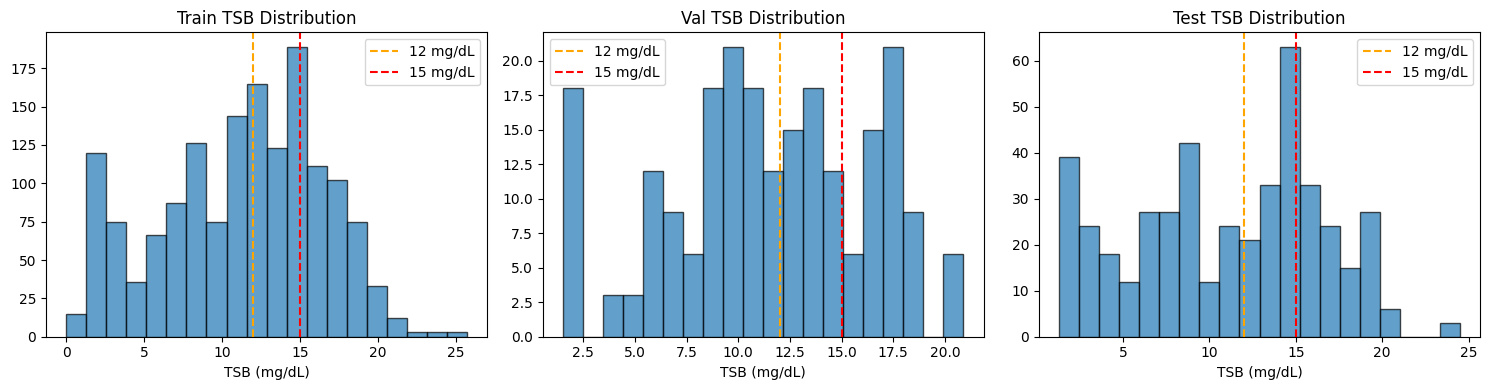

In [18]:
# ── Verify no patient leakage between splits ──
train_pids = set(patient_ids[train_mask])
val_pids = set(patient_ids[val_mask])
test_pids = set(patient_ids[test_mask])

assert len(train_pids & val_pids) == 0, "LEAK: train ∩ val"
assert len(train_pids & test_pids) == 0, "LEAK: train ∩ test"
assert len(val_pids & test_pids) == 0, "LEAK: val ∩ test"
print("✅ No patient leakage between splits")

# Verify visual data is properly normalized
print(f"\n✅ Visual data range: [{X_vis_train.min():.3f}, {X_vis_train.max():.3f}] (should be [0, 1])")
print(f"✅ Visual shape: {X_vis_train.shape} → (samples, {SEQUENCE_LENGTH} skin pixels, 6 channels)")
print(f"✅ Clinical shape: {X_clin_train.shape} → (samples, {len(clinical_features)} features)")
print(f"✅ Clinical features: {clinical_features}")

# Show sample visual sequence stats
sample = X_vis_train[0]
nonzero = np.sum(sample.sum(axis=1) > 0)
print(f"\nSample visual sequence: {nonzero}/{SEQUENCE_LENGTH} non-zero (skin) pixels")

# Target distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, data) in zip(axes, [("Train", y_reg_train), ("Val", y_reg_val), ("Test", y_reg_test)]):
    ax.hist(data, bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(f'{name} TSB Distribution')
    ax.set_xlabel('TSB (mg/dL)')
    ax.axvline(12, color='orange', linestyle='--', label='12 mg/dL')
    ax.axvline(15, color='red', linestyle='--', label='15 mg/dL')
    ax.legend()
plt.tight_layout()
plt.show()

## Step 6: Build Multi-Modal Fusion Model

In [19]:
def build_fusion_model(visual_input_shape, clinical_input_shape,
                       visual_embedding_dim=128, clinical_embedding_dim=64):
    """
    Multi-modal fusion model — deeper visual branch matching paper's Table 2:
    - Visual Branch: 1D-CNN with 4 conv blocks (32→64→128→128) → Embedding(128)
    - Clinical Branch: MLP (Dense→ReLU→Dropout) × 2 → Embedding(64)
    - Fusion: Concatenation → FC Layers + Dropout → Dual Heads
    
    Target: ~500K-1M params so training takes meaningful time and 
    the visual branch can actually learn from 2048×6 skin pixel sequences.
    """

    # === VISUAL BRANCH (1D-CNN) ===
    visual_input = tf.keras.Input(shape=visual_input_shape, name='visual_input')

    # Block 1: Conv1D(32, k=7) → BN → ReLU → MaxPool(2)
    # Wider kernel at start to capture broader color patterns
    x_vis = tf.keras.layers.Conv1D(32, 7, padding='same', name='visual_conv1')(visual_input)
    x_vis = tf.keras.layers.BatchNormalization(name='visual_bn1')(x_vis)
    x_vis = tf.keras.layers.Activation('relu')(x_vis)
    x_vis = tf.keras.layers.MaxPooling1D(2, name='visual_maxpool1')(x_vis)   # 2048 → 1024

    # Block 2: Conv1D(64, k=5) → BN → ReLU → MaxPool(2)
    x_vis = tf.keras.layers.Conv1D(64, 5, padding='same', name='visual_conv2')(x_vis)
    x_vis = tf.keras.layers.BatchNormalization(name='visual_bn2')(x_vis)
    x_vis = tf.keras.layers.Activation('relu')(x_vis)
    x_vis = tf.keras.layers.MaxPooling1D(2, name='visual_maxpool2')(x_vis)   # 1024 → 512

    # Block 3: Conv1D(128, k=3) → BN → ReLU → MaxPool(2)
    x_vis = tf.keras.layers.Conv1D(128, 3, padding='same', name='visual_conv3')(x_vis)
    x_vis = tf.keras.layers.BatchNormalization(name='visual_bn3')(x_vis)
    x_vis = tf.keras.layers.Activation('relu')(x_vis)
    x_vis = tf.keras.layers.MaxPooling1D(2, name='visual_maxpool3')(x_vis)   # 512 → 256

    # Block 4: Conv1D(128, k=3) → BN → ReLU → MaxPool(2)
    x_vis = tf.keras.layers.Conv1D(128, 3, padding='same', name='visual_conv4')(x_vis)
    x_vis = tf.keras.layers.BatchNormalization(name='visual_bn4')(x_vis)
    x_vis = tf.keras.layers.Activation('relu')(x_vis)
    x_vis = tf.keras.layers.MaxPooling1D(2, name='visual_maxpool4')(x_vis)   # 256 → 128

    # Flatten + Dense → Visual Embedding (instead of GlobalAvgPool which loses too much)
    x_vis = tf.keras.layers.Flatten(name='visual_flatten')(x_vis)            # 128 × 128 = 16384
    x_vis = tf.keras.layers.Dense(256, activation='relu', name='visual_dense1')(x_vis)
    x_vis = tf.keras.layers.Dropout(0.5, name='visual_dropout1')(x_vis)
    visual_embedding = tf.keras.layers.Dense(visual_embedding_dim, activation='relu', name='visual_embedding')(x_vis)
    visual_embedding = tf.keras.layers.Dropout(0.3, name='visual_emb_dropout')(visual_embedding)

    # === CLINICAL BRANCH (MLP) ===
    clinical_input = tf.keras.Input(shape=clinical_input_shape, name='clinical_input')

    x_clin = tf.keras.layers.Dense(128, activation='relu', name='clinical_dense1')(clinical_input)
    x_clin = tf.keras.layers.Dropout(0.4, name='clinical_dropout1')(x_clin)
    x_clin = tf.keras.layers.Dense(64, activation='relu', name='clinical_dense2')(x_clin)
    x_clin = tf.keras.layers.Dropout(0.3, name='clinical_dropout2')(x_clin)
    clinical_embedding = tf.keras.layers.Dense(clinical_embedding_dim, activation='relu', name='clinical_embedding')(x_clin)

    # === EMBEDDING FUSION (Concatenation) ===
    fused = tf.keras.layers.Concatenate(name='embedding_fusion')([visual_embedding, clinical_embedding])

    # === FULLY CONNECTED LAYERS + DROPOUT ===
    x_fused = tf.keras.layers.Dense(256, activation='relu', name='fusion_dense1')(fused)
    x_fused = tf.keras.layers.Dropout(0.5, name='fusion_dropout1')(x_fused)

    x_fused = tf.keras.layers.Dense(128, activation='relu', name='fusion_dense2')(x_fused)
    x_fused = tf.keras.layers.Dropout(0.3, name='fusion_dropout2')(x_fused)

    # === DUAL HEADS ===
    regression_head = tf.keras.layers.Dense(1, name='tsb_regression')(x_fused)
    classification_head = tf.keras.layers.Dense(3, activation='softmax', name='risk_classification')(x_fused)

    model = tf.keras.Model(
        inputs=[visual_input, clinical_input],
        outputs=[regression_head, classification_head],
        name='multimodal_fusion_model'
    )

    return model


# Build fusion model
fusion_model = build_fusion_model(
    visual_input_shape=X_vis_train.shape[1:],       # (2048, 6)
    clinical_input_shape=(X_clin_train.shape[1],)    # (5,)
)

fusion_model.summary()
print(f"\nTotal params: {fusion_model.count_params():,}")

Model: "multimodal_fusion_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ visual_input        │ (None, 2048, 6)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ visual_conv1        │ (None, 2048, 32)  │      1,376 │ visual_input[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ visual_bn1          │ (None, 2048, 32)  │        128 │ visual_conv1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 2048, 32)  │          0 │ visual_bn1[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ visual_maxpool1     │ (None, 1024, 32)  │          0 │ activation_4[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ visual_conv2        │ (None, 1024, 64)  │     10,304 │ visual_maxpool1[… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ visual_bn2          │ (None, 1024, 64)  │        256 │ visual_conv2[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 1024, 64)  │          0 │ visual_bn2[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ visual_maxpool2     │ (None, 512, 64)   │          0 │ activation_5[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ visual_conv3        │ (None, 512, 128)  │     24,704 │ visual_maxpool2[… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ visual_bn3          │ (None, 512, 128)  │        512 │ visual_conv3[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 512, 128)  │          0 │ visual_bn3[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ visual_maxpool3     │ (None, 256, 128)  │          0 │ activation_6[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ visual_conv4        │ (None, 256, 128)  │     49,280 │ visual_maxpool3[… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ visual_bn4          │ (None, 256, 128)  │        512 │ visual_conv4[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 256, 128)  │          0 │ visual_bn4[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ visual_maxpool4     │ (None, 128, 128)  │          0 │ activation_7[0][

 Total params: 4,410,532 (16.82 MB)

 Trainable params: 4,409,828 (16.82 MB)

 Non-trainable params: 704 (2.75 KB)


Total params: 4,410,532


## Step 7: Compile Model with Dual Loss Functions

In [20]:
# Compile with dual loss as per methodology
fusion_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=0.01,
        # weight_decay=1e-4
    ),
    loss={
        'tsb_regression': 'mse',
        'risk_classification': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'tsb_regression': 1.0,
        'risk_classification': 0.5
    },
    metrics={
        'tsb_regression': ['mae'],
        'risk_classification': ['accuracy']
    }
)

print("Model compiled:")
print("  Regression loss: MSE | Classification loss: Cross-Entropy")
print("  Optimizer: AdamW (lr=5e-4, weight_decay=1e-4)")
print(f"  Total params: {fusion_model.count_params():,}")

Model compiled:
  Regression loss: MSE | Classification loss: Cross-Entropy
  Optimizer: AdamW (lr=5e-4, weight_decay=1e-4)
  Total params: 4,410,532


## Step 8: Training

In [21]:
# Training callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=15,
    restore_best_weights=True,
    monitor='val_loss'
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=15,
    min_lr=1e-6,
    verbose=1
)

# Train the fusion model
print("Training multi-modal fusion model...")
print(f"  Train: {len(X_vis_train)} | Val: {len(X_vis_val)} | Test: {len(X_vis_test)}")
print(f"  Model params: {fusion_model.count_params():,}")

history = fusion_model.fit(
    [X_vis_train, X_clin_train],
    [y_reg_train, y_cls_train],
    validation_data=([X_vis_val, X_clin_val], [y_reg_val, y_cls_val]),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\nTraining completed in {len(history.history['loss'])} epochs")

Training multi-modal fusion model...
  Train: 1563 | Val: 222 | Test: 450
  Model params: 4,410,532
Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 23051.0234 - risk_classification_accuracy: 0.3947 - risk_classification_loss: 14.0839 - tsb_regression_loss: 23043.1211 - tsb_regression_mae: 47.4243 - val_loss: 28.9605 - val_risk_classification_accuracy: 0.2072 - val_risk_classification_loss: 1.1720 - val_tsb_regression_loss: 28.5264 - val_tsb_regression_mae: 4.6499 - learning_rate: 0.0100
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 33.3066 - risk_classification_accuracy: 0.4379 - risk_classification_loss: 1.8195 - tsb_regression_loss: 32.3975 - tsb_regression_mae: 4.5715 - val_loss: 29.4142 - val_risk_classification_accuracy: 0.5135 - val_risk_classification_loss: 1.7106 - val_tsb_regression_loss: 28.6612 - val_tsb_regression_mae: 4.7739 - learning_rate: 0.0100
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 27.7190 - risk_classification_accuracy: 0.4

## Step 9: Evaluation Strategy (Multiple Metrics)

In [25]:
# ── Evaluate on test set ──
print("=== MODEL EVALUATION (Test Set) ===\n")

# Predictions
y_pred_reg, y_pred_cls_prob = fusion_model.predict([X_vis_test, X_clin_test])
y_pred_reg = y_pred_reg.flatten()
y_pred_cls = np.argmax(y_pred_cls_prob, axis=1)

# === REGRESSION METRICS ===
mse = mean_squared_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mse)                                    # ← CORRECT RMSE
mae = mean_absolute_error(y_reg_test, y_pred_reg)
r2 = r2_score(y_reg_test, y_pred_reg)

print("📊 REGRESSION METRICS (TSB Estimation):")
print(f"  RMSE: {rmse:.4f} mg/dL")
print(f"  MAE:  {mae:.4f} mg/dL")
print(f"  R²:   {r2:.4f}")

# === CLASSIFICATION METRICS ===
accuracy = accuracy_score(y_cls_test, y_pred_cls)
precision, recall, f1, _ = precision_recall_fscore_support(y_cls_test, y_pred_cls, average='weighted', zero_division=0)

print("\n🎯 CLASSIFICATION METRICS (Risk Prediction):")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

# Per-class metrics
print("\n📋 Per-Class Metrics:")
prec_per, rec_per, f1_per, sup_per = precision_recall_fscore_support(
    y_cls_test, y_pred_cls, average=None, zero_division=0
)
risk_labels = ['Low (<12)', 'Medium (12-15)', 'High (>15)']
for i, label in enumerate(risk_labels):
    if i < len(prec_per):
        print(f"  {label}: P={prec_per[i]:.3f} R={rec_per[i]:.3f} F1={f1_per[i]:.3f} (n={sup_per[i]})")

# Confusion Matrix
cm = confusion_matrix(y_cls_test, y_pred_cls)
print(f"\nConfusion Matrix:\n{cm}")

# Overall loss
test_loss = fusion_model.evaluate([X_vis_test, X_clin_test], [y_reg_test, y_cls_test], verbose=0)
print(f"\n📉 Test Losses:")
print(f"  Total: {test_loss[0]:.4f}")
print(f"  Regression (MSE): {test_loss[1]:.4f}")
print(f"  Classification (CE): {test_loss[2]:.4f}")

=== MODEL EVALUATION (Test Set) ===

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
📊 REGRESSION METRICS (TSB Estimation):
  RMSE: 2.7865 mg/dL
  MAE:  2.1446 mg/dL
  R²:   0.7361

🎯 CLASSIFICATION METRICS (Risk Prediction):
  Accuracy:  0.6867
  Precision: 0.5553
  Recall:    0.6867
  F1-Score:  0.6055

📋 Per-Class Metrics:
  Low (<12): P=0.916 R=1.000 F1=0.956 (n=228)
  Medium (12-15): P=0.403 R=0.794 F1=0.535 (n=102)
  High (>15): P=0.000 R=0.000 F1=0.000 (n=120)

Confusion Matrix:
[[228   0   0]
 [ 21  81   0]
 [  0 120   0]]

📉 Test Losses:
  Total: 8.1454
  Regression (MSE): 9.4547
  Classification (CE): 0.7510


## Step 10: Visualize Results

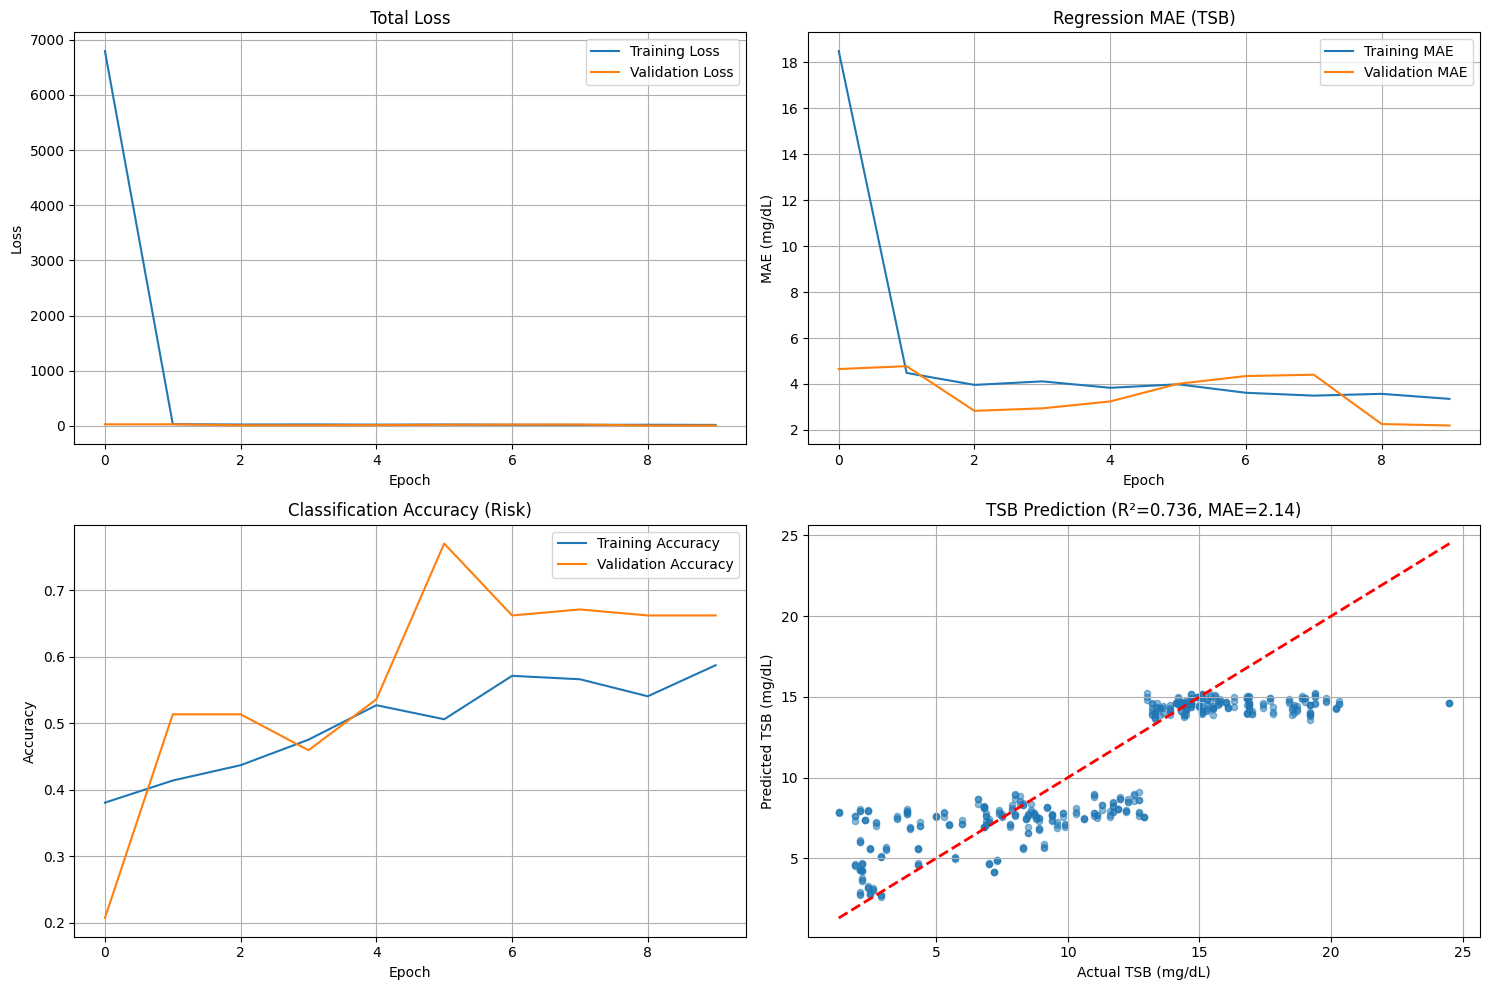

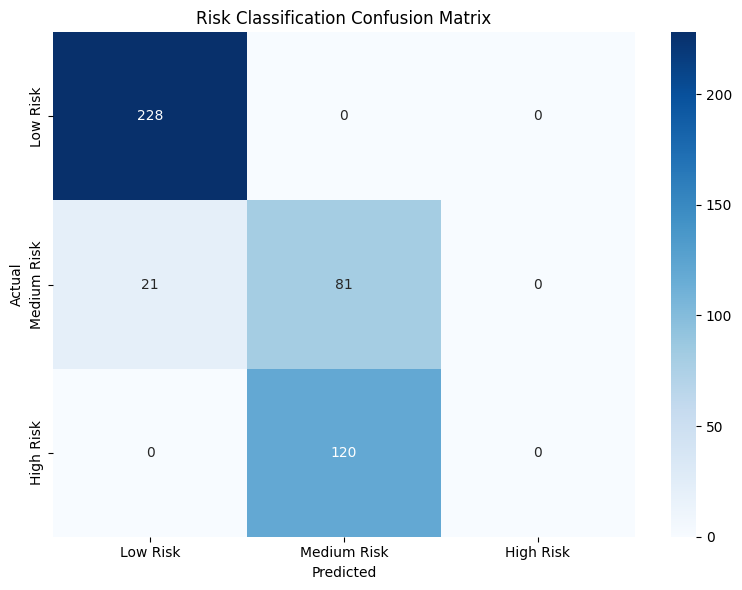

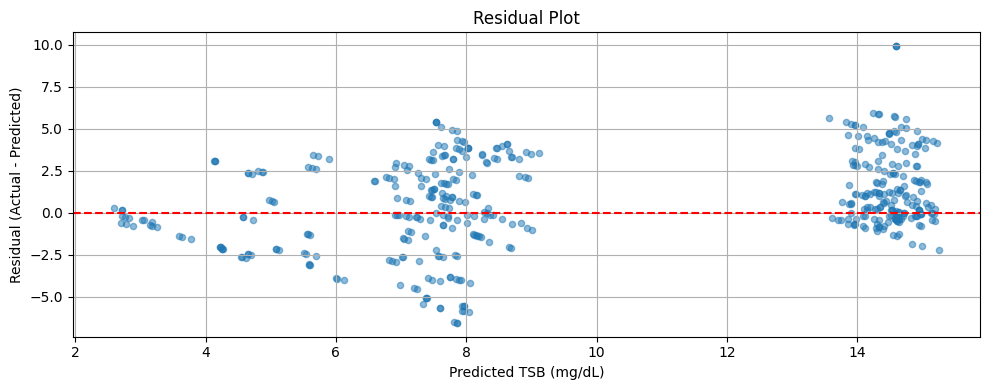

In [23]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Total loss
axes[0,0].plot(history.history['loss'], label='Training Loss')
axes[0,0].plot(history.history['val_loss'], label='Validation Loss')
axes[0,0].set_title('Total Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True)

# Regression MAE
axes[0,1].plot(history.history['tsb_regression_mae'], label='Training MAE')
axes[0,1].plot(history.history['val_tsb_regression_mae'], label='Validation MAE')
axes[0,1].set_title('Regression MAE (TSB)')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('MAE (mg/dL)')
axes[0,1].legend()
axes[0,1].grid(True)

# Classification accuracy
axes[1,0].plot(history.history['risk_classification_accuracy'], label='Training Accuracy')
axes[1,0].plot(history.history['val_risk_classification_accuracy'], label='Validation Accuracy')
axes[1,0].set_title('Classification Accuracy (Risk)')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].legend()
axes[1,0].grid(True)

# Predictions vs Actual (Regression)
axes[1,1].scatter(y_reg_test, y_pred_reg, alpha=0.5, s=20)
axes[1,1].plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2)
axes[1,1].set_xlabel('Actual TSB (mg/dL)')
axes[1,1].set_ylabel('Predicted TSB (mg/dL)')
axes[1,1].set_title(f'TSB Prediction (R²={r2:.3f}, MAE={mae:.2f})')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk', 'Medium Risk', 'High Risk'],
            yticklabels=['Low Risk', 'Medium Risk', 'High Risk'])
plt.title('Risk Classification Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Residual plot
residuals = y_reg_test - y_pred_reg
plt.figure(figsize=(10, 4))
plt.scatter(y_pred_reg, residuals, alpha=0.5, s=20)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted TSB (mg/dL)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 11: Save Complete Multi-Modal Model

In [24]:
# ── Save the complete fusion model and preprocessing artifacts ──
import json

model_save_path = '/Users/shubhbhateja/College/minor_project/development/multimodal_fusion_model.h5'
fusion_model.save(model_save_path)

# Save preprocessing components
preprocessing_data = {
    'clinical_scaler': clinical_scaler,
    'clinical_encoders': clinical_encoders,
    'clinical_features': clinical_features,
    'feature_map': feature_map,
    'target_column': target_col,
    'image_column': image_col,
    'risk_thresholds': [12, 15],
    'img_size': IMG_SIZE,
    'sequence_length': SEQUENCE_LENGTH
}

with open('/Users/shubhbhateja/College/minor_project/development/fusion_preprocessing.pkl', 'wb') as f:
    pickle.dump(preprocessing_data, f)

# Save evaluation results
evaluation_results = {
    'regression_metrics': {
        'rmse': float(rmse),
        'mae': float(mae),
        'r2': float(r2)
    },
    'classification_metrics': {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1)
    },
    'confusion_matrix': cm.tolist(),
    'data_split': {
        'train_patients': len(train_patients),
        'val_patients': len(val_patients),
        'test_patients': len(test_patients),
        'train_samples': int(train_mask.sum()),
        'val_samples': int(val_mask.sum()),
        'test_samples': int(test_mask.sum())
    }
}

with open('/Users/shubhbhateja/College/minor_project/development/evaluation_results.json', 'w') as f:
    json.dump(evaluation_results, f, indent=2)

print("Multi-modal fusion model saved successfully!")
print("📁 Files saved:")
print("  - multimodal_fusion_model.h5")
print("  - fusion_preprocessing.pkl")
print("  - evaluation_results.json")

print(f"\n🎯 FINAL RESULTS SUMMARY:")
print(f"  📈 Regression: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")
print(f"  🎯 Classification: Accuracy={accuracy:.4f}, F1={f1:.4f}")
print(f"  🧪 Evaluated on {len(test_patients)} unseen patients ({test_mask.sum()} images)")

Multi-modal fusion model saved successfully!
📁 Files saved:
  - multimodal_fusion_model.h5
  - fusion_preprocessing.pkl
  - evaluation_results.json

🎯 FINAL RESULTS SUMMARY:
  📈 Regression: RMSE=2.7865, MAE=2.1446, R²=0.7361
  🎯 Classification: Accuracy=0.6867, F1=0.6055
  🧪 Evaluated on 150 unseen patients (450 images)
